In [1]:
%uv pip install torch triton

Using Python 3.12.6 environment at: /usr/local
Audited 2 packages in 22ms
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

import triton
import triton.language as tl

In [3]:
DEVICE = triton.runtime.driver.active.get_active_torch_device()

@triton.jit
def add_kernel(
    x_ptr, y_ptr, out_ptr,
    num_el, BLOCK_SIZE: tl.constexpr
):
    pid = tl.program_id(0)

    block_start = pid * BLOCK_SIZE
    
    offs = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offs < num_el

    x = tl.load(x_ptr+offs, mask=mask)
    y = tl.load(y_ptr+offs, mask=mask)
    output = x+y

    tl.store(out_ptr+offs, output, mask=mask)

In [7]:
def add(x: torch.Tensor, y: torch.Tensor):
    output = torch.empty_like(x)
    assert x.device == DEVICE and y.device == DEVICE
    
    num_el = output.numel()

    grid = lambda meta: (triton.cdiv(num_el, meta['BLOCK_SIZE']), )

    add_kernel[grid](x, y, output, num_el, BLOCK_SIZE=1024)

    return output

In [8]:
torch.manual_seed(0)
size = 1 << 20

x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)

output_torch = x+y
output_triton = add(x, y)

print(f"Max difference: {torch.max(torch.abs(output_torch - output_triton))}")
print(f"Results match: {torch.allclose(output_torch, output_triton)}")

Max difference: 0.0
Results match: True


In [9]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

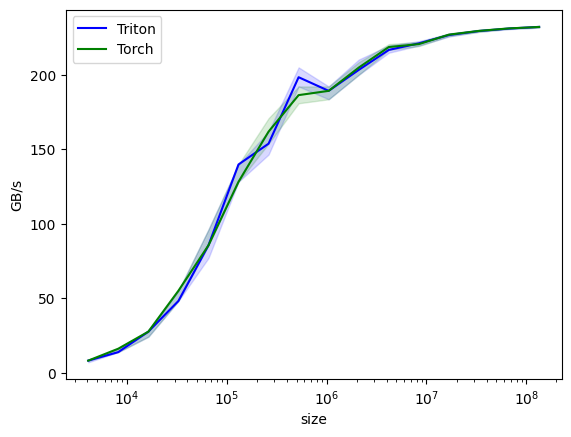

vector-add-performance:
           size      Triton       Torch
0        4096.0    8.000000    8.000000
1        8192.0   13.714286   15.999999
2       16384.0   27.428571   27.428571
3       32768.0   48.000000   54.857142
4       65536.0   85.333330   85.333330
5      131072.0  139.636363  127.999995
6      262144.0  153.600004  161.684218
7      524288.0  198.193551  186.181817
8     1048576.0  189.046153  189.046153
9     2097152.0  203.107443  204.640129
10    4194304.0  216.528637  218.453337
11    8388608.0  220.907859  220.412561
12   16777216.0  226.506919  226.768160
13   33554432.0  229.213637  229.280464
14   67108864.0  230.862169  230.960697
15  134217728.0  231.985835  231.934526


In [10]:
benchmark.run(print_data=True, show_plots=True)